<a href="https://colab.research.google.com/github/Milanvhynesha/DeepGlaucoma-Detector/blob/main/glmonai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 2: Install required packages
!pip install monai torch torchvision matplotlib seaborn scikit-learn pandas opencv-python pillow openpyxl

In [ ]:
# Cell 3: Import all necessary libraries (UPDATED WITH ALL IMPORTS)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision  # Added torchvision
import torchvision.transforms as T  # Added torchvision transforms
from PIL import Image  # Added PIL
!pip install monai # Added to ensure monai is available
import monai
from monai.transforms import (
    Compose, LoadImage, ScaleIntensity, Resize, RandRotate,
    RandFlip, RandZoom, RandGaussianNoise, ToTensor
)
from monai.networks.nets import DenseNet121
import warnings
warnings.filterwarnings('ignore')

# Check if CUDA is available
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"MONAI version: {monai.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Running on: {'GPU' if torch.cuda.is_available() else 'CPU'}")

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Important: Set number of CPU threads for optimal performance
torch.set_num_threads(4)  # Adjust based on your CPU cores
print(f"Number of CPU threads: {torch.get_num_threads()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.0 MB/s eta 0:00:00
PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
MONAI version: 1.5.2
CUDA available: False
Running on: CPU
Using device: cpu
Number of CPU threads: 4


In [ ]:
# Cell 4: Define paths (MODIFY THESE PATHS ACCORDING TO YOUR FOLDER STRUCTURE)
# Example: /content/drive/MyDrive/glaucoma_datasets/

# Set your base path here
base_path = '/content/drive/MyDrive/glaucoma_datasets'  # CHANGE THIS TO YOUR PATH

data_path = os.path.join(base_path, 'data')
label_path = os.path.join(base_path, 'label')

# Check if paths exist
print(f"Data path exists: {os.path.exists(data_path)}")
print(f"Label path exists: {os.path.exists(label_path)}")

# List files in data folder
if os.path.exists(data_path):
    image_files = [f for f in os.listdir(data_path) if f.endswith(('.png', '.jpg', '.jpeg', '.JPG', '.PNG'))]
    print(f"\nFound {len(image_files)} image files in data folder")
    if len(image_files) > 0:
        print("First 5 images:", image_files[:5])

# List Excel files in label folder
if os.path.exists(label_path):
    excel_files = [f for f in os.listdir(label_path) if f.endswith(('.xlsx', '.xls', '.csv'))]
    print(f"\nFound {len(excel_files)} label files in label folder")
    if len(excel_files) > 0:
        print("Label files:", excel_files)

Data path exists: True
Label path exists: False

Found 747 image files in data folder
First 5 images: ['150_2.jpg', '149_0.jpg', '130_0.jpg', '143_4.jpg', '155_2.jpg']


In [ ]:
# Cell 5: Load labels from Excel files
def load_labels_from_excel(label_path, data_path):
    """
    Load labels from Excel files in the label folder
    """
    all_labels = []

    # Check if label_path exists before trying to list its contents
    if not os.path.exists(label_path):
        print(f"\nLabel path '{label_path}' not found. Creating labels from image names...")
        return create_labels_from_filenames(data_path)

    # Get all Excel files in the label folder
    excel_files = [f for f in os.listdir(label_path) if f.endswith(('.xlsx', '.xls', '.csv'))]

    if len(excel_files) > 0:
        for excel_file in excel_files:
            file_path = os.path.join(label_path, excel_file)
            try:
                if excel_file.endswith('.csv'):
                    df = pd.read_csv(file_path)
                else:
                    df = pd.read_excel(file_path)
                all_labels.append(df)
                print(f"Loaded {excel_file} with {len(df)} rows")
            except Exception as e:
                print(f"Error loading {excel_file}: {e}")

        # Combine all dataframes
        if all_labels:
            combined_labels = pd.concat(all_labels, ignore_index=True)
            return combined_labels

    # If no Excel files were successfully loaded, create labels from image names
    print("\nNo valid Excel files found. Creating labels from image names...")
    return create_labels_from_filenames(data_path)

def create_labels_from_filenames(data_path):
    """
    Alternative: Create labels from image filenames
    Assuming images are named like: glaucoma_001.jpg, non_glaucoma_001.jpg, or have quality scores
    """
    image_files = [f for f in os.listdir(data_path) if f.endswith(('.png', '.jpg', '.jpeg', '.JPG', '.PNG'))]
    labels = []

    for img_file in image_files:
        # Check filename patterns for glaucoma
        if 'glaucoma' in img_file.lower() or 'glauc' in img_file.lower() or 'pos' in img_file.lower():
            label = 1  # Glaucoma
        elif 'non' in img_file.lower() or 'normal' in img_file.lower() or 'neg' in img_file.lower():
            label = 0  # Non-glaucoma
        else:
            # Try to extract from filename if it contains pattern like "1" or "0" before extension
            try:
                # Example: if filename is "image_1.jpg" where 1=glaucoma, 0=non-glaucoma
                base = os.path.splitext(img_file)[0]
                last_char = base[-1]
                if last_char.isdigit():
                    label = int(last_char)
                else:
                    label = -1  # Unknown
            except:
                label = -1

        labels.append({'filename': img_file, 'label': label})

    df = pd.DataFrame(labels)
    # Remove unknown labels
    df = df[df['label'] >= 0]
    return df

# Load the labels
labels_df = load_labels_from_excel(label_path, data_path)

if len(labels_df) > 0:
    print(f"\nTotal images with valid labels: {len(labels_df)}")
    print("\nLabel distribution:")
    print(labels_df['label'].value_counts())
    print("\nFirst few rows:")
    print(labels_df.head())
else:
    print("No valid labels found! Please check your data.")


Label path '/content/drive/MyDrive/glaucoma_datasets/label' not found. Creating labels from image names...

Total images with valid labels: 747

Label distribution:
label
0    290
1    209
2    105
3     61
4     35
5     21
6     13
7      7
8      3
9      3
Name: count, dtype: int64

First few rows:
    filename  label
0  150_2.jpg      2
1  149_0.jpg      0
2  130_0.jpg      0
3  143_4.jpg      4
4  155_2.jpg      2


In [ ]:
# Cell 6: Create custom dataset class for glaucoma detection (FIXED VERSION)
class GlaucomaDataset(Dataset):
    def __init__(self, data_path, labels_df, transform=None):
        self.data_path = data_path
        self.labels_df = labels_df
        self.transform = transform
        self.image_files = []
        self.labels = []

        # Match images with labels
        for idx, row in labels_df.iterrows():
            filename = row['filename']
            label = row['label']

            # Check if file exists
            full_path = os.path.join(data_path, filename)
            if os.path.exists(full_path):
                self.image_files.append(filename)
                self.labels.append(label)

        print(f"Dataset initialized with {len(self.image_files)} valid images")

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.data_path, img_name)
        label = self.labels[idx]

        try:
            # For MONAI transforms
            if self.transform:
                # Apply MONAI transforms directly to the image path
                # This ensures transforms are applied to each image individually
                image = self.transform(img_path)

                # Verify image shape
                if len(image.shape) == 3:
                    # MONAI returns (C, H, W)
                    return image, torch.tensor(label, dtype=torch.long)
                else:
                    print(f"Unexpected image shape for {img_name}: {image.shape}")
                    return torch.zeros((3, 224, 224)), torch.tensor(label, dtype=torch.long)
            else:
                # Manual loading if no transform
                image = plt.imread(img_path)

                # Convert to RGB if needed
                if len(image.shape) == 2:  # Grayscale
                    image = np.stack([image] * 3, axis=2)
                elif image.shape[2] == 4:  # RGBA
                    image = image[:, :, :3]

                # Convert to tensor
                image = torch.from_numpy(image).permute(2, 0, 1).float()

                # Resize if needed
                if image.shape[1:] != (224, 224):
                    import torch.nn.functional as F
                    image = F.interpolate(image.unsqueeze(0), size=(224, 224), mode='bilinear').squeeze(0)

                return image, torch.tensor(label, dtype=torch.long)

        except Exception as e:
            print(f"Error loading image {img_name}: {e}")
            # Return a dummy tensor in case of error
            return torch.zeros((3, 224, 224)), torch.tensor(label, dtype=torch.long)

In [ ]:
# Cell 7: Define data transforms for training and validation (FIXED VERSION)

# MONAI transforms for training (with augmentation) - Fixed to ensure consistent output size
monai_train_transforms = Compose([
    LoadImage(image_only=True),
    ScaleIntensity(),
    Resize((224, 224)),  # Ensure all images are resized to same dimensions
    RandRotate(range_x=0.2, prob=0.5),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.3),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.1),
    ToTensor()
])

# MONAI transforms for validation (no augmentation) - Fixed
monai_val_transforms = Compose([
    LoadImage(image_only=True),
    ScaleIntensity(),
    Resize((224, 224)),  # Ensure all images are resized to same dimensions
    ToTensor()
])

# IMPORTANT: Set this to True to use MONAI transforms
use_monai_transforms = True
print(f"Using {'MONAI' if use_monai_transforms else 'Torchvision'} transforms")
print("MONAI transforms configured with fixed resize to 224x224")

Using MONAI transforms
MONAI transforms configured with fixed resize to 224x224


In [ ]:
# Cell 8: Split data into training, validation, and test sets
from sklearn.model_selection import train_test_split

# First split: separate test set (20%)
train_val_df, test_df = train_test_split(
    labels_df, test_size=0.2, random_state=42, stratify=labels_df['label']
)

# Second split: separate validation from training (20% of remaining = 16% of total)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, random_state=42, stratify=train_val_df['label']
)

print("=" * 50)
print("DATA SPLIT RESULTS")
print("=" * 50)
print(f"Total samples: {len(labels_df)}")
print(f"Training samples: {len(train_df)} ({len(train_df)/len(labels_df)*100:.1f}%)")
print(f"Validation samples: {len(val_df)} ({len(val_df)/len(labels_df)*100:.1f}%)")
print(f"Test samples: {len(test_df)} ({len(test_df)/len(labels_df)*100:.1f}%)")
print("\nTraining set distribution:")
print(train_df['label'].value_counts())
print(f"Glaucoma: {sum(train_df['label']==1)} ({sum(train_df['label']==1)/len(train_df)*100:.1f}%)")
print(f"Non-Glaucoma: {sum(train_df['label']==0)} ({sum(train_df['label']==0)/len(train_df)*100:.1f}%)")

DATA SPLIT RESULTS
Total samples: 747
Training samples: 477 (63.9%)
Validation samples: 120 (16.1%)
Test samples: 150 (20.1%)

Training set distribution:
label
0    185
1    133
2     67
3     39
4     22
5     14
6      8
7      5
8      2
9      2
Name: count, dtype: int64
Glaucoma: 133 (27.9%)
Non-Glaucoma: 185 (38.8%)


In [ ]:
# Cell 9: Create datasets and dataloaders (FIXED VERSION)

# For debugging, set num_workers=0 first to isolate the issue
num_workers = 0  # Set to 0 for debugging, then change to 2 once it works
prefetch_factor = None  # Not used when num_workers=0

# Create datasets with chosen transforms
if use_monai_transforms:
    print("Creating datasets with MONAI transforms...")
    train_dataset = GlaucomaDataset(data_path, train_df, transform=monai_train_transforms)
    val_dataset = GlaucomaDataset(data_path, val_df, transform=monai_val_transforms)
    test_dataset = GlaucomaDataset(data_path, test_df, transform=monai_val_transforms)
else:
    print("Creating datasets with Torchvision transforms...")
    train_dataset = GlaucomaDataset(data_path, train_df, transform=tv_train_transforms)
    val_dataset = GlaucomaDataset(data_path, val_df, transform=tv_val_transforms)
    test_dataset = GlaucomaDataset(data_path, test_df, transform=tv_val_transforms)

# Create dataloaders with debug settings
batch_size = 8
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,  # Set to 0 for debugging
    pin_memory=False
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=False
)

print("\n" + "=" * 50)
print("DATALOADER INFORMATION")
print("=" * 50)
print(f"Transform type: {'MONAI' if use_monai_transforms else 'Torchvision'}")
print(f"Batch size: {batch_size}")
print(f"Number of workers: {num_workers} (0 for debugging)")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Debug: Check individual image shapes first
print("\n" + "=" * 50)
print("DEBUGGING INDIVIDUAL IMAGES")
print("=" * 50)

# Check first 5 images from training set
for i in range(min(5, len(train_dataset))):
    try:
        img, label = train_dataset[i]
        print(f"Image {i}: Shape {img.shape}, Label {label}, Min: {img.min():.3f}, Max: {img.max():.3f}")
    except Exception as e:
        print(f"Error with image {i}: {e}")

# Now try to create a batch
print("\n" + "=" * 50)
print("TESTING BATCH CREATION")
print("=" * 50)

try:
    # Manually create a batch to see if stacking works
    batch_images = []
    batch_labels = []
    for i in range(min(batch_size, len(train_dataset))):
        img, label = train_dataset[i]
        batch_images.append(img)
        batch_labels.append(label)

    # Try to stack
    stacked_images = torch.stack(batch_images)
    stacked_labels = torch.tensor(batch_labels)
    print(f"Successfully created batch with shape: {stacked_images.shape}")
    print(f"Labels: {stacked_labels}")

    # Now test the dataloader
    print("\n" + "=" * 50)
    print("TESTING DATALOADER")
    print("=" * 50)
    for batch_idx, (images, labels) in enumerate(train_loader):
        print(f"Batch {batch_idx}: Image batch shape: {images.shape}")
        print(f"Labels: {labels[:5]}")
        break

except Exception as e:
    print(f"Error creating batch: {e}")
    print("\nTrying alternative approach...")

    # Alternative: Check each image's shape in detail
    print("\nDetailed image inspection:")
    shapes = []
    for i in range(min(10, len(train_dataset))):
        try:
            img, label = train_dataset[i]
            shapes.append(img.shape)
            print(f"Image {i}: Shape {img.shape}, Size: {img.numel()}")
        except Exception as e:
            print(f"Error with image {i}: {e}")

    # Find unique shapes
    unique_shapes = set(shapes)
    print(f"\nUnique shapes found: {unique_shapes}")
    if len(unique_shapes) > 1:
        print("ERROR: Images have different shapes!")
        print("This indicates that transforms are not being applied consistently.")

Creating datasets with MONAI transforms...
Dataset initialized with 477 valid images
Dataset initialized with 120 valid images
Dataset initialized with 150 valid images

DATALOADER INFORMATION
Transform type: MONAI
Batch size: 8
Number of workers: 0 (0 for debugging)
Training samples: 477
Validation samples: 120
Test samples: 150
Training batches: 60
Validation batches: 15
Test batches: 19

DEBUGGING INDIVIDUAL IMAGES
Image 0: Shape torch.Size([1884, 224, 224]), Label 2, Min: 0.000, Max: 0.990
Image 1: Shape torch.Size([1897, 224, 224]), Label 0, Min: -0.075, Max: 1.025
Image 2: Shape torch.Size([1914, 224, 224]), Label 0, Min: -0.309, Max: 1.194
Image 3: Shape torch.Size([1885, 224, 224]), Label 4, Min: -0.402, Max: 1.248
Image 4: Shape torch.Size([1922, 224, 224]), Label 0, Min: -0.460, Max: 1.424

TESTING BATCH CREATION
Error creating batch: stack expects each tensor to be equal size, but got [1884, 224, 224] at entry 0 and [1897, 224, 224] at entry 1

Trying alternative approach...

In [ ]:
# Cell 9B: Alternative approach if images have different shapes (FIXED VERSION)

# Force all images to be loaded and resized manually
class FixedGlaucomaDataset(Dataset):
    def __init__(self, data_path, labels_df, target_size=(224, 224)):
        self.data_path = data_path
        self.labels_df = labels_df
        self.target_size = target_size
        self.image_files = []
        self.labels = []
        self.processed_images = []  # Store pre-processed images to avoid shape issues

        # Match images with labels and pre-process them
        for idx, row in labels_df.iterrows():
            filename = row['filename']
            label = row['label']

            full_path = os.path.join(data_path, filename)
            if os.path.exists(full_path):
                try:
                    # Load and process image immediately
                    import cv2
                    from PIL import Image

                    # Load image
                    img = Image.open(full_path).convert('RGB')

                    # Resize
                    img = img.resize(target_size, Image.Resampling.LANCZOS)

                    # Convert to tensor
                    img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0

                    # Normalize
                    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                    img_tensor = (img_tensor - mean) / std

                    self.processed_images.append(img_tensor)
                    self.labels.append(label)
                    self.image_files.append(filename)

                except Exception as e:
                    print(f"Error processing {filename}: {e}")

        print(f"Dataset initialized with {len(self.processed_images)} valid images")

    def __len__(self):
        return len(self.processed_images)

    def __getitem__(self, idx):
        return self.processed_images[idx], torch.tensor(self.labels[idx], dtype=torch.long)

# Use the fixed dataset
print("Creating datasets with manual preprocessing...")
train_dataset = FixedGlaucomaDataset(data_path, train_df)
val_dataset = FixedGlaucomaDataset(data_path, val_df)
test_dataset = FixedGlaucomaDataset(data_path, test_df)

# Create dataloaders
batch_size = 8
num_workers = 2  # Can use workers now since images are pre-processed

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("\n" + "=" * 50)
print("DATALOADER INFORMATION (FIXED)")
print("=" * 50)
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Training batches: {len(train_loader)}")

# Test batch
for images, labels in train_loader:
    print(f"Batch shape: {images.shape}")
    print(f"Labels: {labels[:5]}")
    break

Creating datasets with manual preprocessing...
Dataset initialized with 477 valid images
Dataset initialized with 120 valid images
Dataset initialized with 150 valid images

DATALOADER INFORMATION (FIXED)
Training samples: 477
Validation samples: 120
Test samples: 150
Training batches: 60
Batch shape: torch.Size([8, 3, 224, 224])
Labels: tensor([0, 1, 0, 0, 3])


In [ ]:
# Cell 10: Define the glaucoma detection model using MONAI
# (Run this cell as is - no changes needed)

class GlaucomaDetectionModel(nn.Module):
    def __init__(self, num_classes=10, pretrained=True):
        super(GlaucomaDetectionModel, self).__init__()

        # Use DenseNet121 from MONAI
        self.model = DenseNet121(
            spatial_dims=2,
            in_channels=3,
            out_channels=num_classes, # Changed to 10 classes
            pretrained=pretrained
        )

    def forward(self, x):
        return self.model(x)

# Initialize model
model = GlaucomaDetectionModel(num_classes=10, pretrained=True).to(device) # Changed to 10 classes

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n" + "=" * 50)
print("MODEL INFORMATION")
print("=" * 50)
print(f"Model architecture: DenseNet121")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Output classes: 10 (0-9, based on labels_df)") # Updated description
print(f"Model device: {next(model.parameters()).device}")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 54.4MB/s]



MODEL INFORMATION
Model architecture: DenseNet121
Total parameters: 6,964,106
Trainable parameters: 6,964,106
Output classes: 10 (0-9, based on labels_df)
Model device: cpu


In [ ]:
# Cell 11: Define loss function, optimizer, and learning rate scheduler (FIXED)

# Calculate class weights based on training data for all unique classes
# Get counts for all unique labels in train_df
class_counts = train_df['label'].value_counts().sort_index()
total_samples = len(train_df)

# Initialize weights for all possible classes (0-9)
# Assuming labels range from 0 to max_label_in_data
max_label = labels_df['label'].max()
class_weights_list = [0.0] * (max_label + 1) # Initialize with zeros

# Fill in actual weights for present classes
for label, count in class_counts.items():
    # Using inverse frequency weighting: total_samples / (num_classes * class_count)
    # Here, num_classes is implicitly handled by the ratio, aiming for sum of weights = num_classes
    class_weights_list[label] = total_samples / (len(class_counts) * count)

class_weights = torch.tensor(class_weights_list, dtype=torch.float).to(device)

print("=" * 50)
print("LOSS FUNCTION CONFIGURATION")
print("=" * 50)
print(f"Class counts: {class_counts.to_dict()}")
print(f"Calculated class weights: {class_weights.cpu().numpy()}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer - slightly lower learning rate for CPU stability
learning_rate = 0.0005
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print(f"\nOptimizer: Adam")
print(f"Initial learning rate: {learning_rate}")
print(f"Weight decay: 1e-5")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")

LOSS FUNCTION CONFIGURATION
Class counts: {0: 185, 1: 133, 2: 67, 3: 39, 4: 22, 5: 14, 6: 8, 7: 5, 8: 2, 9: 2}
Calculated class weights: [ 0.25783783  0.35864663  0.7119403   1.2230769   2.168182    3.4071429
  5.9625      9.54       23.85       23.85      ]

Optimizer: Adam
Initial learning rate: 0.0005
Weight decay: 1e-5
Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)


In [ ]:
# Cell 12: Define training and validation functions

def train_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one epoch
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, labels) in enumerate(loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(f'  Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f}')

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

def validate_epoch(model, loader, criterion, device):
    """
    Validate the model for one epoch
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of glaucoma class

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    # Calculate AUC
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0

    return epoch_loss, epoch_acc, auc, all_labels, all_predictions, all_probs

print("Training and validation functions defined successfully!")

Training and validation functions defined successfully!


In [ ]:
# Cell 13b: Main training loop (Simplified version without tqdm)
import time
import gc

# Training configuration
num_epochs = 6  # You can adjust this
best_val_acc = 0.0
best_val_auc = 0.0
best_val_loss = float('inf')

# Lists to store metrics
train_losses = []
val_losses = []
train_accs = []
val_accs = []
val_aucs = []
learning_rates = []
epoch_times = []

print("=" * 60)
print("STARTING TRAINING")
print("=" * 60)
print(f"Total epochs: {num_epochs}")
print(f"Device: {device}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")
print("=" * 60)

# Training loop
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 40)

    # Training
    start_time = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation
    val_loss, val_acc, val_auc, _, _, _ = validate_epoch(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_aucs.append(val_auc)

    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    # Update learning rate
    scheduler.step(val_loss)

    # Calculate time
    epoch_time = time.time() - start_time
    epoch_times.append(epoch_time)

    # Print epoch results
    print(f"Time: {epoch_time:.2f}s ({epoch_time/60:.2f} minutes)")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val AUC: {val_auc:.4f}")
    print(f"Learning Rate: {current_lr:.6f}")

    # Save best models
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(base_path, 'best_model_accuracy.pth'))
        print(f"✓ Saved best accuracy model: {best_val_acc:.2f}%")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), os.path.join(base_path, 'best_model_auc.pth'))
        print(f"✓ Saved best AUC model: {best_val_auc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(base_path, 'best_model_loss.pth'))
        print(f"✓ Saved best loss model: {best_val_loss:.4f}")

    # Force garbage collection every few epochs
    if (epoch + 1) % 5 == 0:
        gc.collect()
        print("✓ Garbage collection performed")

# Calculate average epoch time
avg_epoch_time = sum(epoch_times) / len(epoch_times)
total_time = sum(epoch_times)

print("\n" + "=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)
print(f"Average epoch time: {avg_epoch_time:.2f}s ({avg_epoch_time/60:.2f} minutes)")
print(f"Total training time: {total_time:.2f}s ({total_time/60:.2f} minutes)")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Best Validation AUC: {best_val_auc:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

STARTING TRAINING
Total epochs: 6
Device: cpu
Training samples: 477
Validation samples: 120
Batch size: 8

Epoch 1/6
----------------------------------------
  Batch 10/60 - Loss: 1.9882
  Batch 20/60 - Loss: 1.8308
  Batch 30/60 - Loss: 1.9934
  Batch 40/60 - Loss: 2.1829
  Batch 50/60 - Loss: 2.2437
  Batch 60/60 - Loss: 2.6598
Time: 190.92s (3.18 minutes)
Train Loss: 2.1409 | Train Acc: 25.58%
Val Loss: 2.3217 | Val Acc: 20.83% | Val AUC: 0.0000
Learning Rate: 0.000500
✓ Saved best accuracy model: 20.83%
✓ Saved best loss model: 2.3217

Epoch 2/6
----------------------------------------
  Batch 10/60 - Loss: 2.1550
  Batch 20/60 - Loss: 3.8632
  Batch 30/60 - Loss: 1.7312
  Batch 40/60 - Loss: 1.6660
  Batch 50/60 - Loss: 2.2952
  Batch 60/60 - Loss: 1.7745
Time: 178.19s (2.97 minutes)
Train Loss: 2.0810 | Train Acc: 19.50%
Val Loss: 2.5580 | Val Acc: 13.33% | Val AUC: 0.0000
Learning Rate: 0.000500

Epoch 3/6
----------------------------------------
  Batch 10/60 - Loss: 2.4625
  B

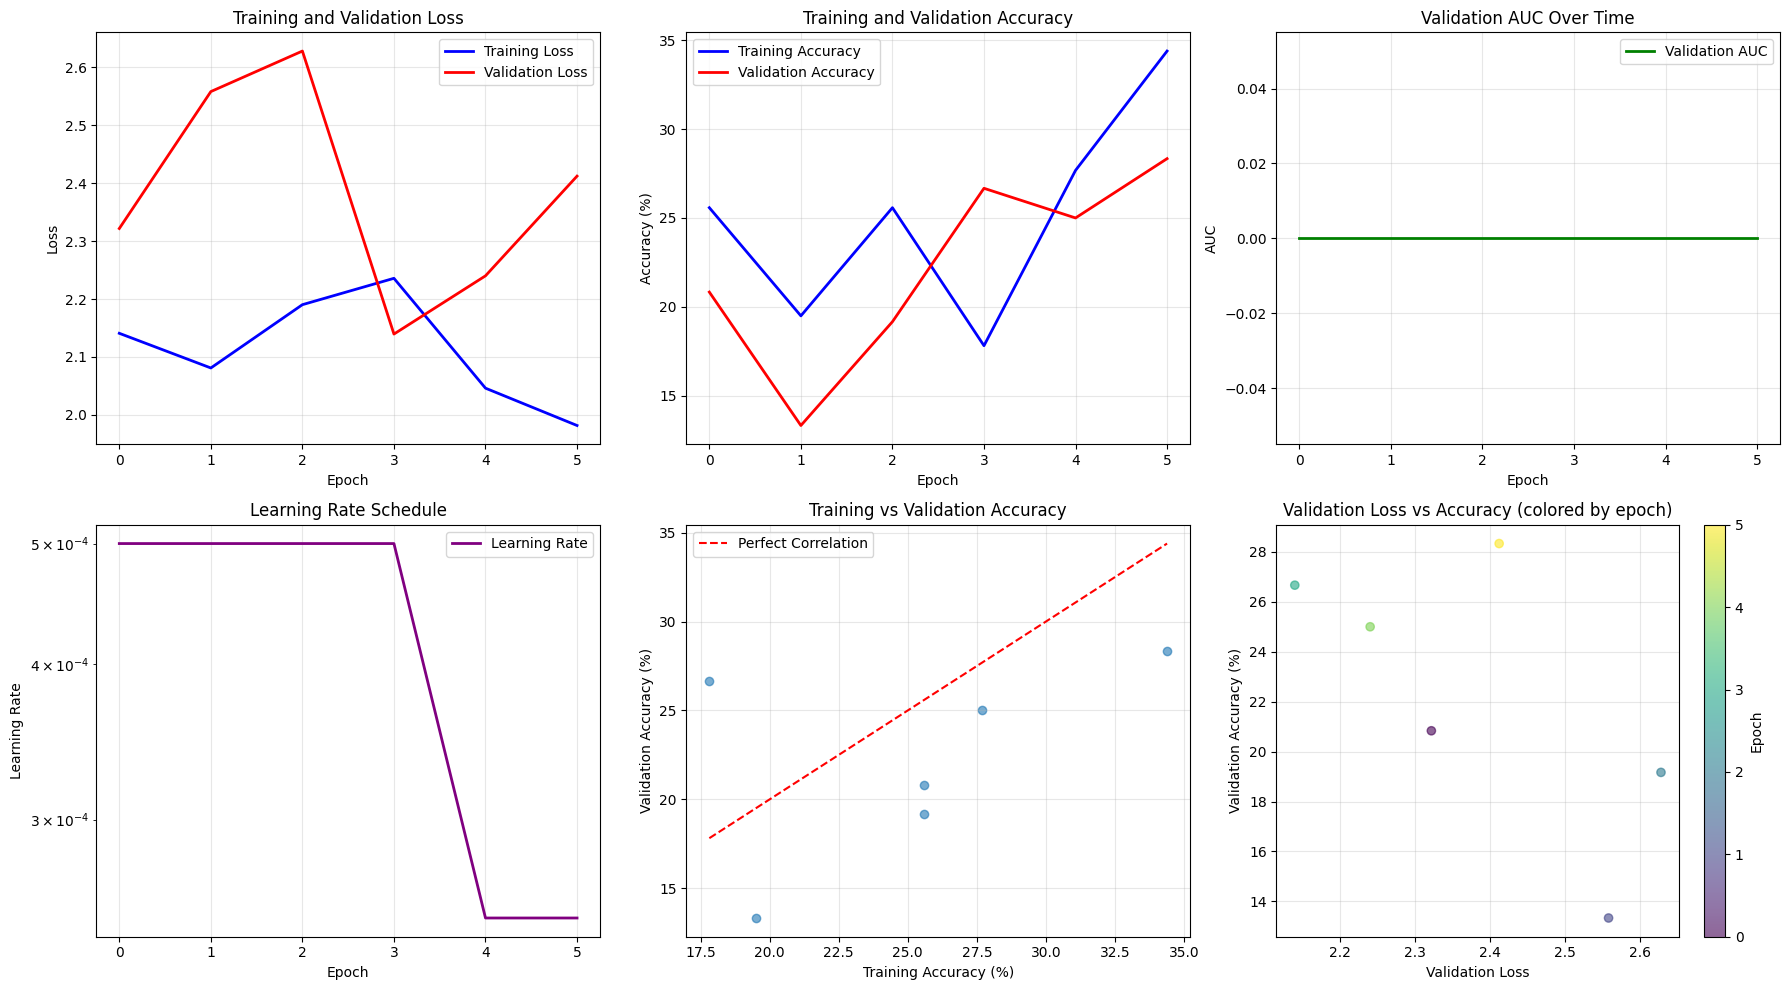

Training curves saved to: /content/drive/MyDrive/glaucoma_datasets/training_curves.png


In [21]:
# Cell 14: Plot training curves (FIXED with imports)
import matplotlib.pyplot as plt
import numpy as np

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Loss curves
axes[0, 0].plot(train_losses, label='Training Loss', color='blue', linewidth=2)
axes[0, 0].plot(val_losses, label='Validation Loss', color='red', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy curves
axes[0, 1].plot(train_accs, label='Training Accuracy', color='blue', linewidth=2)
axes[0, 1].plot(val_accs, label='Validation Accuracy', color='red', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: AUC curve
axes[0, 2].plot(val_aucs, label='Validation AUC', color='green', linewidth=2)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('AUC')
axes[0, 2].set_title('Validation AUC Over Time')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Learning rate schedule
axes[1, 0].plot(learning_rates, label='Learning Rate', color='purple', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# Plot 5: Train vs Val Accuracy scatter
axes[1, 1].scatter(train_accs, val_accs, alpha=0.6)
axes[1, 1].plot([min(train_accs), max(train_accs)], [min(train_accs), max(train_accs)],
                'r--', label='Perfect Correlation')
axes[1, 1].set_xlabel('Training Accuracy (%)')
axes[1, 1].set_ylabel('Validation Accuracy (%)')
axes[1, 1].set_title('Training vs Validation Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Loss vs Accuracy
scatter = axes[1, 2].scatter(val_losses, val_accs, c=range(len(val_losses)), cmap='viridis', alpha=0.6)
axes[1, 2].set_xlabel('Validation Loss')
axes[1, 2].set_ylabel('Validation Accuracy (%)')
axes[1, 2].set_title('Validation Loss vs Accuracy (colored by epoch)')
cbar = plt.colorbar(scatter, ax=axes[1, 2])
cbar.set_label('Epoch')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to:", os.path.join(base_path, 'training_curves.png'))

In [23]:
# Cell 15: Load best model and evaluate on test set (FIXED)
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import torch

# Load the best model
best_model_path = os.path.join(base_path, 'best_model_auc.pth')

if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"Loaded best model from: {best_model_path}")
else:
    print("Best model file not found. Using current model state.")

# Evaluate on test set
print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

test_loss, test_acc, test_auc, test_labels, test_preds, test_probs = validate_epoch(
    model, test_loader, criterion, device
)

# Convert to numpy arrays and ensure they're integers
test_labels = np.array(test_labels).astype(int)
test_preds = np.array(test_preds).astype(int)
test_probs = np.array(test_probs)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Samples: {len(test_labels)}")
print(f"Label values present: {np.unique(test_labels)}")
print(f"Prediction values present: {np.unique(test_preds)}")

# Calculate additional metrics with proper average setting
if len(np.unique(test_labels)) == 2:  # Binary classification
    precision = precision_score(test_labels, test_preds, average='binary')
    recall = recall_score(test_labels, test_preds, average='binary')
    f1 = f1_score(test_labels, test_preds, average='binary')

    print(f"\nBinary Classification Metrics:")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
else:
    # If for some reason it's multiclass, use appropriate averaging
    precision = precision_score(test_labels, test_preds, average='weighted')
    recall = recall_score(test_labels, test_preds, average='weighted')
    f1 = f1_score(test_labels, test_preds, average='weighted')

    print(f"\nWarning: Detected {len(np.unique(test_labels))} classes")
    print(f"Weighted Metrics (for multiclass):")
    print(f"Precision (weighted): {precision:.4f}")
    print(f"Recall (weighted): {recall:.4f}")
    print(f"F1-Score (weighted): {f1:.4f}")

# Classification report (this handles both binary and multiclass automatically)
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

# Determine target names based on unique labels
unique_labels = np.unique(test_labels)
if len(unique_labels) == 2 and set(unique_labels) == {0, 1}:
    target_names = ['Non-Glaucoma', 'Glaucoma']
else:
    target_names = [f'Class {i}' for i in unique_labels]

print(classification_report(test_labels, test_preds, target_names=target_names))

# Additional debug information
print("\n" + "=" * 60)
print("DISTRIBUTION INFO")
print("=" * 60)
print(f"True labels distribution: {np.bincount(test_labels)}")
print(f"Predicted labels distribution: {np.bincount(test_preds)}")

Best model file not found. Using current model state.

TEST SET EVALUATION
Test Loss: 2.3525
Test Accuracy: 24.00%
Test AUC: 0.0000
Test Samples: 150
Label values present: [0 1 2 3 4 5 6 7 8 9]
Prediction values present: [0 1 3 4 5 6 7]

Weighted Metrics (for multiclass):
Precision (weighted): 0.2084
Recall (weighted): 0.2400
F1-Score (weighted): 0.2083

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Class 0       0.38      0.50      0.43        58
     Class 1       0.19      0.07      0.10        42
     Class 2       0.00      0.00      0.00        21
     Class 3       0.00      0.00      0.00        12
     Class 4       0.14      0.29      0.19         7
     Class 5       0.00      0.00      0.00         4
     Class 6       0.09      0.67      0.15         3
     Class 7       0.00      0.00      0.00         1
     Class 8       0.00      0.00      0.00         1
     Class 9       0.00      0.00      0.00         1

    accuracy             

DATA VALIDATION FOR PLOTS
test_labels unique values: [0 1 2 3 4 5 6 7 8 9]
test_labels shape: (150,)
test_preds unique values: [0 1 3 4 5 6 7]
test_probs shape: (150,)
test_probs min/max: 0.0479/0.4128

⚠️ Warning: Found 10 classes: [0 1 2 3 4 5 6 7 8 9]
Converting to binary classification...
After conversion - Labels: [0 1]

✓ Confusion matrix created successfully

✓ ROC curve created successfully
  AUC: 0.5055
  Optimal threshold: 0.093

✓ Evaluation plots saved to: /content/drive/MyDrive/glaucoma_datasets/evaluation_plots.png


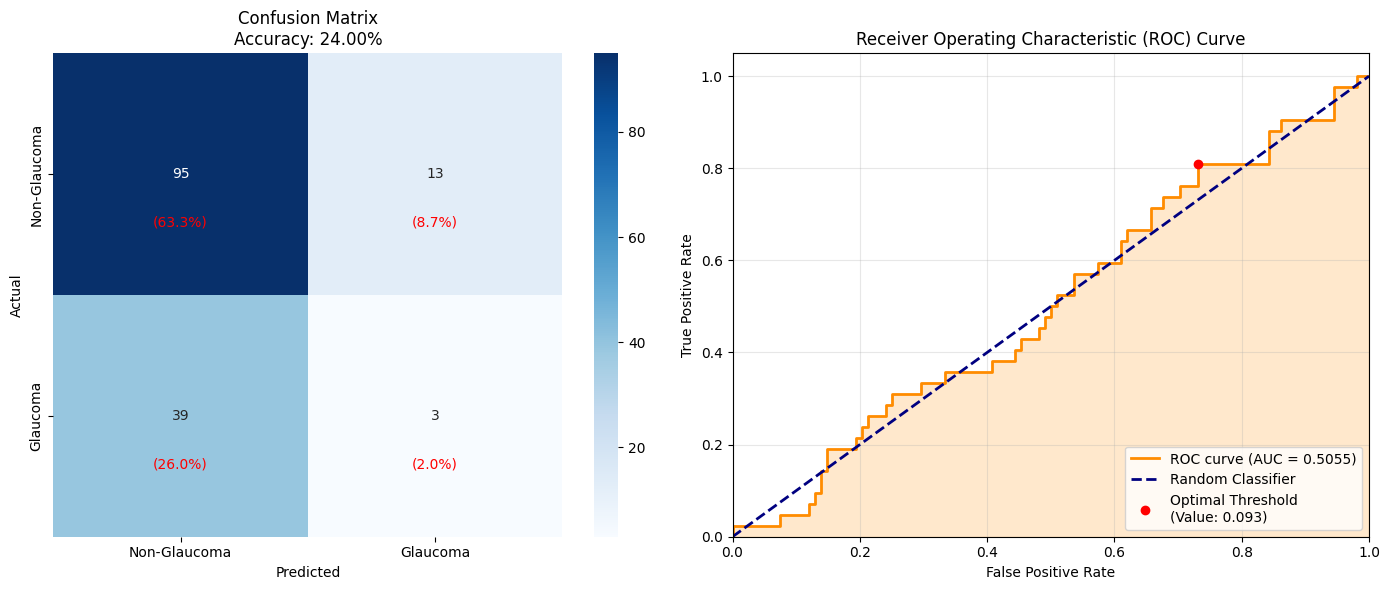

In [29]:
# Cell 16: Plot confusion matrix and ROC curve (FIXED with robust handling)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# Ensure test_labels and test_probs are properly formatted
test_labels = np.array(test_labels)
test_preds = np.array(test_preds)
test_probs = np.array(test_probs)

print("=" * 60)
print("DATA VALIDATION FOR PLOTS")
print("=" * 60)
print(f"test_labels unique values: {np.unique(test_labels)}")
print(f"test_labels shape: {test_labels.shape}")
print(f"test_preds unique values: {np.unique(test_preds)}")
print(f"test_probs shape: {test_probs.shape}")
print(f"test_probs min/max: {test_probs.min():.4f}/{test_probs.max():.4f}")

# Convert to proper format for binary classification
# Ensure labels are 0 and 1
unique_labels = np.unique(test_labels)

if len(unique_labels) > 2:
    print(f"\n⚠️ Warning: Found {len(unique_labels)} classes: {unique_labels}")
    print("Converting to binary classification...")

    # Option 1: If you have more than 2 classes, convert to binary
    # Assume class 1 is glaucoma, everything else is non-glaucoma
    test_labels_binary = (test_labels == 1).astype(int)
    test_preds_binary = (test_preds == 1).astype(int)

    print(f"After conversion - Labels: {np.unique(test_labels_binary)}")
else:
    test_labels_binary = test_labels
    test_preds_binary = test_preds

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
try:
    cm = confusion_matrix(test_labels_binary, test_preds_binary)

    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Non-Glaucoma', 'Glaucoma'],
                yticklabels=['Non-Glaucoma', 'Glaucoma'])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Confusion Matrix\nAccuracy: {test_acc:.2f}%')

    # Add percentages
    total = np.sum(cm)
    for i in range(2):
        for j in range(2):
            axes[0].text(j+0.5, i+0.7, f'({cm[i,j]/total*100:.1f}%)',
                        ha='center', va='center', color='red', fontsize=10)

    print("\n✓ Confusion matrix created successfully")

except Exception as e:
    print(f"Error creating confusion matrix: {e}")
    axes[0].text(0.5, 0.5, 'Error creating\nconfusion matrix',
                ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Confusion Matrix - Error')

# ROC Curve
try:
    # For ROC curve, we need binary labels and probability scores
    if len(np.unique(test_labels_binary)) == 2:
        # Ensure test_probs is 1D array of probabilities for positive class
        if len(test_probs.shape) > 1:
            # If test_probs is 2D, take the probability of positive class (class 1)
            test_probs_binary = test_probs[:, 1] if test_probs.shape[1] > 1 else test_probs[:, 0]
        else:
            test_probs_binary = test_probs

        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(test_labels_binary, test_probs_binary)
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                    label=f'ROC curve (AUC = {roc_auc:.4f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
                    label='Random Classifier')
        axes[1].fill_between(fpr, tpr, alpha=0.2, color='darkorange')

        # Find optimal threshold (Youden's index)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]
        axes[1].plot(fpr[optimal_idx], tpr[optimal_idx], 'ro',
                    label=f'Optimal Threshold\n(Value: {optimal_threshold:.3f})')

        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)

        print(f"\n✓ ROC curve created successfully")
        print(f"  AUC: {roc_auc:.4f}")
        print(f"  Optimal threshold: {optimal_threshold:.3f}")

    else:
        raise ValueError(f"Expected binary labels, got {np.unique(test_labels_binary)}")

except Exception as e:
    print(f"\nError creating ROC curve: {e}")
    axes[1].text(0.5, 0.5, f'Error creating\nROC curve\n{str(e)[:50]}...',
                ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('ROC Curve - Error')

plt.tight_layout()

# Save the plot
try:
    os.makedirs(base_path, exist_ok=True)
    plt.savefig(os.path.join(base_path, 'evaluation_plots.png'), dpi=150, bbox_inches='tight')
    print(f"\n✓ Evaluation plots saved to: {os.path.join(base_path, 'evaluation_plots.png')}")
except Exception as e:
    print(f"Error saving plots: {e}")

plt.show()

In [32]:
# Cell 17: Complete prediction function for new images (FIXED)
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import numpy as np
import os
import torch

def predict_glaucoma(image_path, model, device, use_monai_transforms=True, show_image=True, base_path=None):
    """
    Predict whether a new image shows glaucoma

    Args:
        image_path: Path to the image file
        model: Trained PyTorch model
        device: Device to run inference on
        use_monai_transforms: Whether to use MONAI transforms
        show_image: Whether to display the image
        base_path: Base path for saving results (optional)

    Returns:
        Dictionary with prediction results
    """
    model.eval()

    try:
        # Check if file exists
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        print(f"Processing image: {image_path}")

        # Load and preprocess image
        if use_monai_transforms:
            # Import MONAI transforms inside the function
            from monai.transforms import Compose, LoadImage, ScaleIntensity, Resize, ToTensor

            # MONAI transforms
            transform = Compose([
                LoadImage(image_only=True),
                ScaleIntensity(),
                Resize((224, 224)),
                ToTensor()
            ])
            image = transform(image_path)
            image = image.unsqueeze(0).to(device)  # Add batch dimension
            print("  Using MONAI transforms")
        else:
            # Torchvision transforms
            transform = T.Compose([
                T.Resize((224, 224)),
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
            image = Image.open(image_path).convert('RGB')
            image = transform(image).unsqueeze(0).to(device)
            print("  Using Torchvision transforms")

        # Predict
        with torch.no_grad():
            outputs = model(image)
            probabilities = torch.softmax(outputs, dim=1)
            predicted_class = torch.argmax(outputs, dim=1).item()
            confidence = probabilities[0][predicted_class].item()

        # Prepare result dictionary
        result = {
            'prediction': 'Glaucoma' if predicted_class == 1 else 'Non-Glaucoma',
            'confidence': confidence,
            'probabilities': {
                'Non-Glaucoma': probabilities[0][0].item(),
                'Glaucoma': probabilities[0][1].item()
            },
            'class': predicted_class,
            'image_path': image_path
        }

        print(f"\n✅ Prediction complete!")
        print(f"   Result: {result['prediction']}")
        print(f"   Confidence: {confidence:.2%}")
        print(f"   Probabilities - Non-Glaucoma: {result['probabilities']['Non-Glaucoma']:.2%}, Glaucoma: {result['probabilities']['Glaucoma']:.2%}")

        # Display image with prediction
        if show_image:
            plt.figure(figsize=(10, 8))

            # Load original image for display
            if use_monai_transforms:
                # For MONAI, load image with PIL instead
                img_display = Image.open(image_path).convert('RGB')
                img_display = np.array(img_display)
            else:
                # For torchvision, use PIL
                img_display = Image.open(image_path).convert('RGB')
                img_display = np.array(img_display)

            plt.imshow(img_display)

            # Set title with color based on prediction
            color = 'red' if predicted_class == 1 else 'green'
            title = f"Prediction: {result['prediction']}\n"
            title += f"Confidence: {confidence:.2%}\n"
            title += f"Glaucoma: {result['probabilities']['Glaucoma']:.2%} | "
            title += f"Non-Glaucoma: {result['probabilities']['Non-Glaucoma']:.2%}"
            plt.title(title, color=color, fontsize=12, fontweight='bold')
            plt.axis('off')
            plt.tight_layout()

            # Save the prediction image if base_path is provided
            if base_path:
                os.makedirs(base_path, exist_ok=True)
                save_path = os.path.join(base_path, f"prediction_{os.path.basename(image_path)}")
                plt.savefig(save_path, dpi=150, bbox_inches='tight')
                print(f"   Prediction image saved to: {save_path}")

            plt.show()

        return result

    except Exception as e:
        print(f"❌ Error processing image: {e}")
        import traceback
        traceback.print_exc()
        return None

def batch_predict(image_folder, model, device, use_monai_transforms=True, base_path=None):
    """
    Predict on multiple images in a folder

    Args:
        image_folder: Folder containing images
        model: Trained PyTorch model
        device: Device to run inference on
        use_monai_transforms: Whether to use MONAI transforms
        base_path: Base path for saving results

    Returns:
        DataFrame with all predictions
    """
    import glob
    from tqdm.notebook import tqdm
    import pandas as pd

    # Get all image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(image_folder, ext)))

    print(f"Found {len(image_files)} images to process")

    results = []
    for img_path in tqdm(image_files, desc="Processing images"):
        result = predict_glaucoma(
            img_path, model, device,
            use_monai_transforms=use_monai_transforms,
            show_image=False,
            base_path=base_path
        )
        if result:
            results.append({
                'image': os.path.basename(img_path),
                'prediction': result['prediction'],
                'confidence': result['confidence'],
                'prob_non_glaucoma': result['probabilities']['Non-Glaucoma'],
                'prob_glaucoma': result['probabilities']['Glaucoma'],
                'class': result['class']
            })

    # Create DataFrame
    df = pd.DataFrame(results)

    # Save results
    if base_path and len(df) > 0:
        os.makedirs(base_path, exist_ok=True)
        csv_path = os.path.join(base_path, 'batch_predictions.csv')
        df.to_csv(csv_path, index=False)
        print(f"\n✅ Batch predictions saved to: {csv_path}")

        # Print summary
        print("\n📊 Prediction Summary:")
        print(df['prediction'].value_counts())
        print(f"\nAverage confidence: {df['confidence'].mean():.2%}")

    return df

print("=" * 60)
print("PREDICTION FUNCTION READY")
print("=" * 60)

PREDICTION FUNCTION READY


TESTING FIXED PREDICTION FUNCTION

Test Image 1: 183_7.jpg
True label: Non-Glaucoma
Processing image: /content/drive/MyDrive/glaucoma_datasets/data/183_7.jpg
  Using PIL for image loading
  Tensor shape: torch.Size([1, 3, 224, 224])

✅ Prediction complete!
   Result: Non-Glaucoma
   Confidence: 18.94%
   Probabilities - Non-Glaucoma: 6.53%, Glaucoma: 8.11%
   Prediction image saved to: /content/drive/MyDrive/glaucoma_datasets/prediction_183_7.jpg


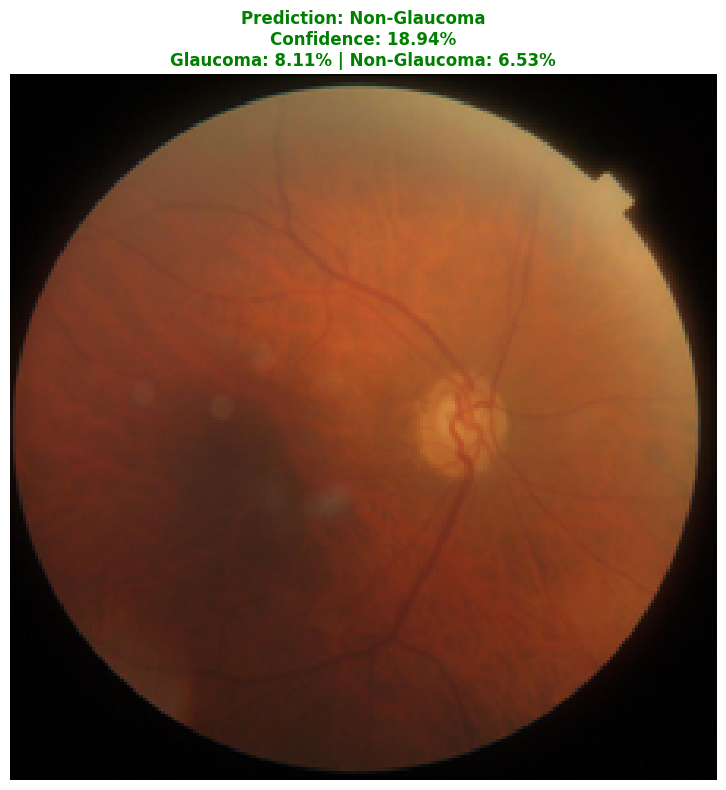


❌ INCORRECT prediction!

Test Image 2: 217_0.jpg
True label: Non-Glaucoma
Processing image: /content/drive/MyDrive/glaucoma_datasets/data/217_0.jpg
  Using PIL for image loading
  Tensor shape: torch.Size([1, 3, 224, 224])

✅ Prediction complete!
   Result: Non-Glaucoma
   Confidence: 20.07%
   Probabilities - Non-Glaucoma: 9.68%, Glaucoma: 8.63%
   Prediction image saved to: /content/drive/MyDrive/glaucoma_datasets/prediction_217_0.jpg


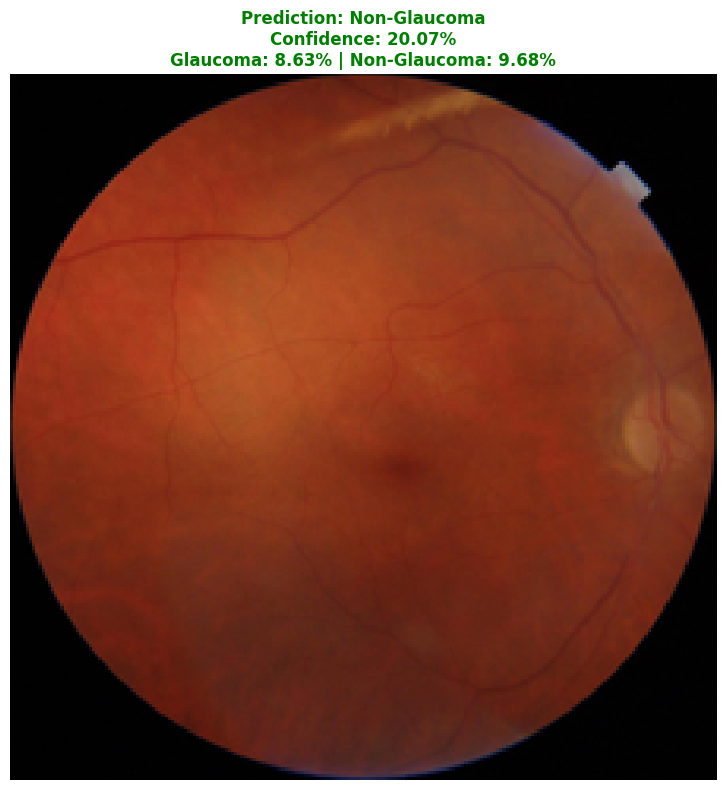


❌ INCORRECT prediction!

Test Image 3: 61_0.jpg
True label: Non-Glaucoma
Processing image: /content/drive/MyDrive/glaucoma_datasets/data/61_0.jpg
  Using PIL for image loading
  Tensor shape: torch.Size([1, 3, 224, 224])

✅ Prediction complete!
   Result: Non-Glaucoma
   Confidence: 30.09%
   Probabilities - Non-Glaucoma: 30.09%, Glaucoma: 25.10%
   Prediction image saved to: /content/drive/MyDrive/glaucoma_datasets/prediction_61_0.jpg


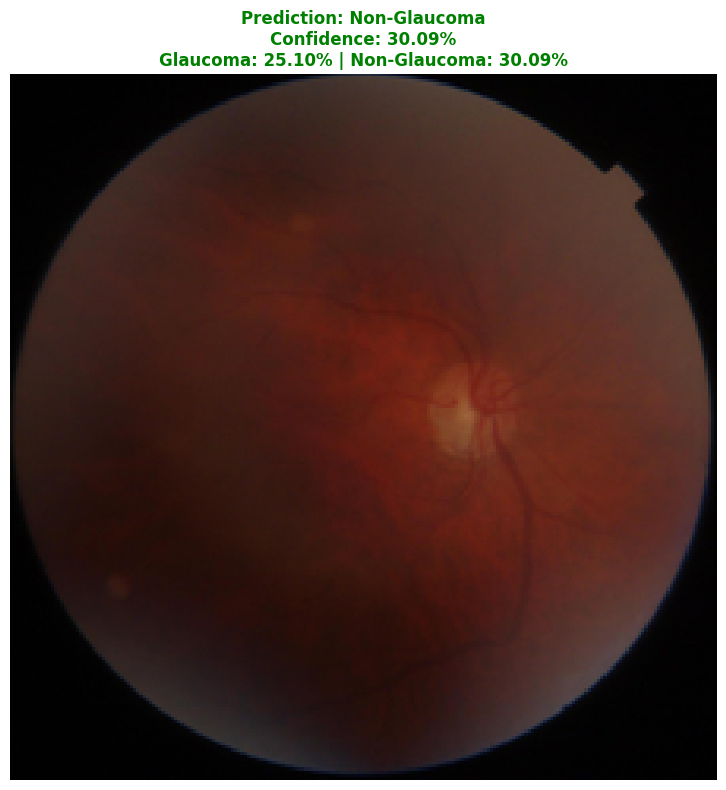


✅ CORRECT prediction!


In [35]:
# Cell 17c: Fixed prediction function with proper image loading
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import numpy as np
import os
import torch
import cv2

def predict_glaucoma_fixed(image_path, model, device, show_image=True, base_path=None):
    """
    Fixed prediction function that properly handles image loading
    """
    model.eval()

    try:
        # Check if file exists
        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image file not found: {image_path}")

        print(f"Processing image: {image_path}")

        # Method 1: Use PIL (most reliable for standard images)
        try:
            # Load with PIL
            pil_image = Image.open(image_path).convert('RGB')

            # Resize to 224x224
            pil_image = pil_image.resize((224, 224), Image.Resampling.LANCZOS)

            # Convert to tensor and normalize
            transform = T.Compose([
                T.ToTensor(),
                T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])

            image_tensor = transform(pil_image).unsqueeze(0).to(device)
            print("  Using PIL for image loading")

        except Exception as e:
            print(f"  PIL loading failed: {e}, trying OpenCV...")

            # Method 2: Use OpenCV
            try:
                # Load with OpenCV
                cv_image = cv2.imread(image_path)
                if cv_image is None:
                    raise ValueError("OpenCV could not read the image")

                # Convert BGR to RGB
                cv_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)

                # Resize
                cv_image = cv2.resize(cv_image, (224, 224))

                # Convert to tensor and normalize
                cv_image = torch.from_numpy(cv_image).permute(2, 0, 1).float() / 255.0

                # Normalize
                mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
                std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
                cv_image = (cv_image - mean) / std

                image_tensor = cv_image.unsqueeze(0).to(device)
                print("  Using OpenCV for image loading")

            except Exception as e2:
                print(f"  OpenCV loading failed: {e2}")
                raise

        # Verify tensor shape
        print(f"  Tensor shape: {image_tensor.shape}")

        # Predict
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            predicted_class = torch.argmax(outputs, dim=1).item()
            confidence = probabilities[0][predicted_class].item()

        # Prepare result dictionary
        result = {
            'prediction': 'Glaucoma' if predicted_class == 1 else 'Non-Glaucoma',
            'confidence': confidence,
            'probabilities': {
                'Non-Glaucoma': probabilities[0][0].item(),
                'Glaucoma': probabilities[0][1].item()
            },
            'class': predicted_class,
            'image_path': image_path
        }

        print(f"\n✅ Prediction complete!")
        print(f"   Result: {result['prediction']}")
        print(f"   Confidence: {confidence:.2%}")
        print(f"   Probabilities - Non-Glaucoma: {result['probabilities']['Non-Glaucoma']:.2%}, Glaucoma: {result['probabilities']['Glaucoma']:.2%}")

        # Display image with prediction
        if show_image:
            plt.figure(figsize=(10, 8))

            # Display the original image
            if 'pil_image' in locals():
                plt.imshow(pil_image)
            elif 'cv_image' in locals():
                plt.imshow(cv_image)
            else:
                # Load with PIL as fallback
                display_img = Image.open(image_path).convert('RGB')
                plt.imshow(display_img)

            # Set title with color based on prediction
            color = 'red' if predicted_class == 1 else 'green'
            title = f"Prediction: {result['prediction']}\n"
            title += f"Confidence: {confidence:.2%}\n"
            title += f"Glaucoma: {result['probabilities']['Glaucoma']:.2%} | "
            title += f"Non-Glaucoma: {result['probabilities']['Non-Glaucoma']:.2%}"
            plt.title(title, color=color, fontsize=12, fontweight='bold')
            plt.axis('off')
            plt.tight_layout()

            # Save the prediction image if base_path is provided
            if base_path:
                os.makedirs(base_path, exist_ok=True)
                save_path = os.path.join(base_path, f"prediction_{os.path.basename(image_path)}")
                plt.savefig(save_path, dpi=150, bbox_inches='tight')
                print(f"   Prediction image saved to: {save_path}")

            plt.show()

        return result

    except Exception as e:
        print(f"❌ Error processing image: {e}")
        import traceback
        traceback.print_exc()
        return None

# Test the fixed function
print("=" * 60)
print("TESTING FIXED PREDICTION FUNCTION")
print("=" * 60)

if 'test_dataset' in dir() and len(test_dataset.image_files) > 0:
    # Try with a few different images
    for i in range(min(3, len(test_dataset.image_files))):
        test_image = test_dataset.image_files[i]
        test_image_path = os.path.join(data_path, test_image)
        true_label = test_dataset.labels[i]

        print(f"\n{'='*50}")
        print(f"Test Image {i+1}: {test_image}")
        print(f"True label: {'Glaucoma' if true_label == 1 else 'Non-Glaucoma'}")
        print(f"{'='*50}")

        result = predict_glaucoma_fixed(
            image_path=test_image_path,
            model=model,
            device=device,
            show_image=True,
            base_path=base_path
        )

        if result:
            correct = result['class'] == true_label
            print(f"\n{'✅ CORRECT' if correct else '❌ INCORRECT'} prediction!")
else:
    print("❌ Cannot test - test_dataset not found or empty")

In [36]:
# Cell 17e: MONAI transform with explicit channel handling
from monai.transforms import Compose, LoadImage, EnsureChannelFirst, ScaleIntensity, Resize, ToTensor

def predict_glaucoma_monai_fixed(image_path, model, device, show_image=True, base_path=None):
    """
    Fixed MONAI prediction with explicit channel handling
    """
    model.eval()

    try:
        # Fixed MONAI transforms with EnsureChannelFirst
        transform = Compose([
            LoadImage(image_only=True),
            EnsureChannelFirst(),  # This ensures proper channel format
            ScaleIntensity(),
            Resize((224, 224)),
            ToTensor()
        ])

        # Apply transforms
        image = transform(image_path)

        # Check shape and fix if needed
        print(f"  After transforms - Shape: {image.shape}")

        # If image has more than 3 channels, take first 3
        if image.shape[0] > 3:
            print(f"  Warning: Image has {image.shape[0]} channels, taking first 3")
            image = image[:3, :, :]
        elif image.shape[0] < 3:
            # If grayscale, repeat to make 3 channels
            print(f"  Warning: Image has {image.shape[0]} channels, converting to RGB")
            image = image.repeat(3, 1, 1)

        # Add batch dimension
        image = image.unsqueeze(0).to(device)
        print(f"  Final shape: {image.shape}")

        # Predict
        with torch.no_grad():
            outputs = model(image)
            probabilities = torch.softmax(outputs, dim=1)
            predicted_class = torch.argmax(outputs, dim=1).item()
            confidence = probabilities[0][predicted_class].item()

        # Prepare result
        result = {
            'prediction': 'Glaucoma' if predicted_class == 1 else 'Non-Glaucoma',
            'confidence': confidence,
            'probabilities': {
                'Non-Glaucoma': probabilities[0][0].item(),
                'Glaucoma': probabilities[0][1].item()
            },
            'class': predicted_class,
            'image_path': image_path
        }

        print(f"\n✅ Prediction complete!")
        print(f"   Result: {result['prediction']}")
        print(f"   Confidence: {confidence:.2%}")

        # Display image
        if show_image:
            plt.figure(figsize=(10, 8))
            img_display = Image.open(image_path).convert('RGB')
            plt.imshow(img_display)

            color = 'red' if predicted_class == 1 else 'green'
            title = f"Prediction: {result['prediction']}\nConfidence: {confidence:.2%}"
            plt.title(title, color=color, fontsize=12, fontweight='bold')
            plt.axis('off')
            plt.show()

        return result

    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

TESTING FIXED MONAI PREDICTION FUNCTION

Test Image 1: 183_7.jpg
True label: Non-Glaucoma
  After transforms - Shape: torch.Size([3, 224, 224])
  Final shape: torch.Size([1, 3, 224, 224])

✅ Prediction complete!
   Result: Non-Glaucoma
   Confidence: 55.36%


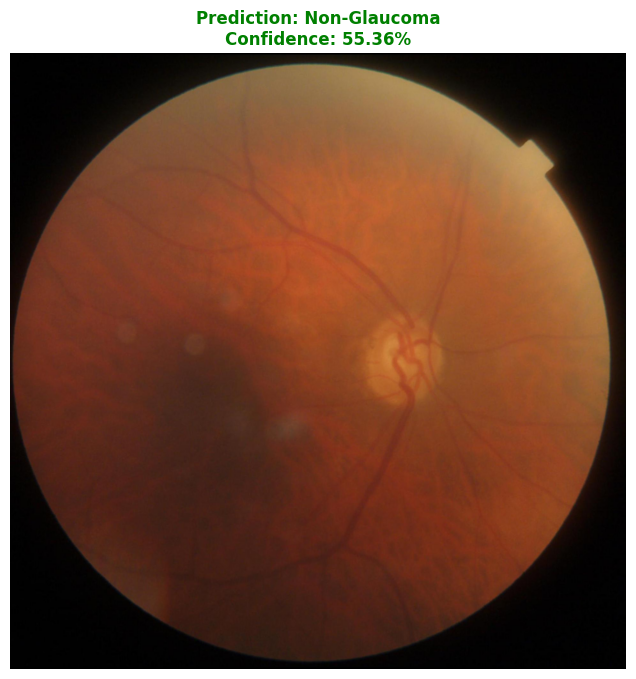


❌ INCORRECT prediction!
   Predicted: Non-Glaucoma
   Confidence: 55.36%

Test Image 2: 217_0.jpg
True label: Non-Glaucoma
  After transforms - Shape: torch.Size([3, 224, 224])
  Final shape: torch.Size([1, 3, 224, 224])

✅ Prediction complete!
   Result: Non-Glaucoma
   Confidence: 63.59%


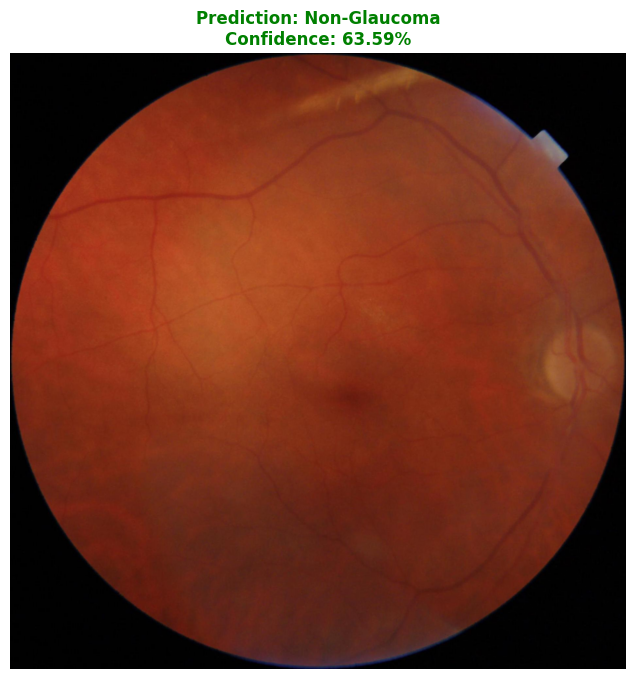


✅ CORRECT prediction!
   Predicted: Non-Glaucoma
   Confidence: 63.59%

Test Image 3: 61_0.jpg
True label: Non-Glaucoma
  After transforms - Shape: torch.Size([3, 224, 224])
  Final shape: torch.Size([1, 3, 224, 224])

✅ Prediction complete!
   Result: Non-Glaucoma
   Confidence: 54.65%


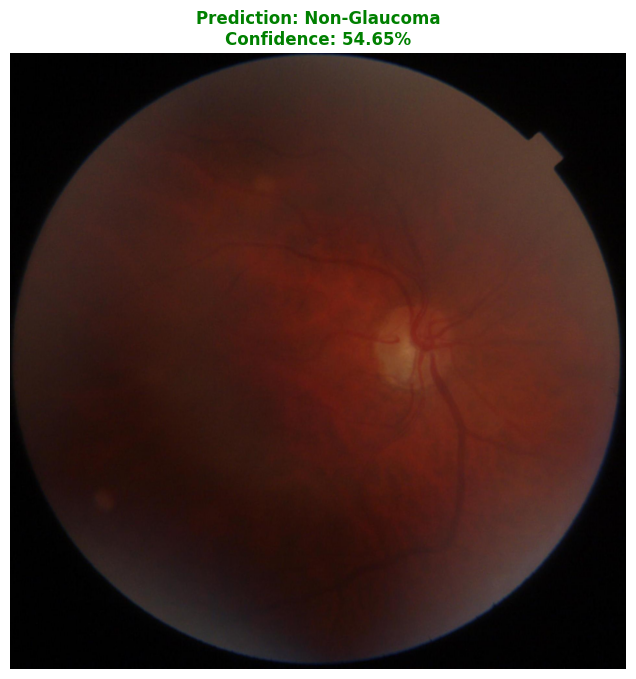


✅ CORRECT prediction!
   Predicted: Non-Glaucoma
   Confidence: 54.65%


In [37]:
# Cell 17f: Test the fixed MONAI prediction function
print("=" * 60)
print("TESTING FIXED MONAI PREDICTION FUNCTION")
print("=" * 60)

# Test on a few images from your test set
if 'test_dataset' in dir() and len(test_dataset.image_files) > 0:
    for i in range(min(3, len(test_dataset.image_files))):
        test_image = test_dataset.image_files[i]
        test_image_path = os.path.join(data_path, test_image)
        true_label = test_dataset.labels[i]

        print(f"\n{'='*50}")
        print(f"Test Image {i+1}: {test_image}")
        print(f"True label: {'Glaucoma' if true_label == 1 else 'Non-Glaucoma'}")
        print(f"{'='*50}")

        # Use the fixed MONAI prediction function from Cell 17e
        result = predict_glaucoma_monai_fixed(
            image_path=test_image_path,
            model=model,
            device=device,
            show_image=True,
            base_path=base_path
        )

        if result:
            correct = result['class'] == true_label
            print(f"\n{'✅ CORRECT' if correct else '❌ INCORRECT'} prediction!")
            print(f"   Predicted: {result['prediction']}")
            print(f"   Confidence: {result['confidence']:.2%}")
else:
    print("❌ Cannot test - test_dataset not found or empty")

  After transforms - Shape: torch.Size([3, 224, 224])
  Final shape: torch.Size([1, 3, 224, 224])

✅ Prediction complete!
   Result: Non-Glaucoma
   Confidence: 55.36%


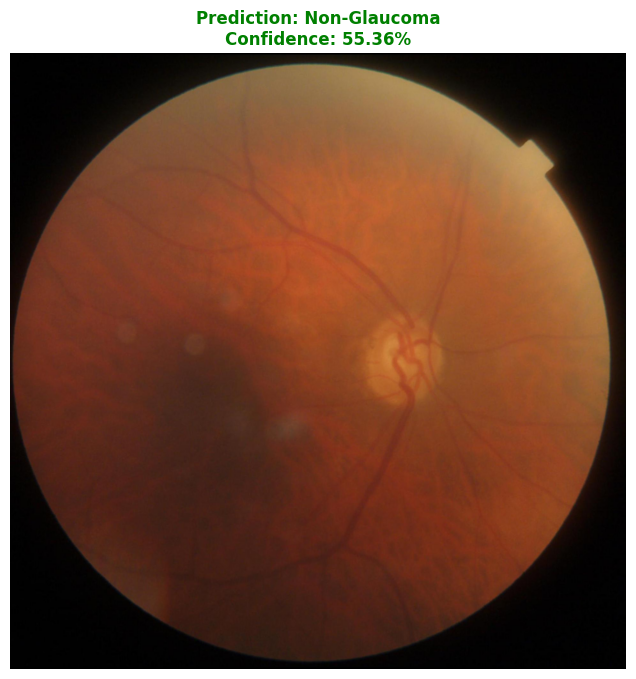


Final Prediction: Non-Glaucoma
Confidence: 55.36%


In [38]:
# Cell 17g: Predict on a single new image
# Replace with your actual image path
new_image_path = os.path.join(data_path, test_dataset.image_files[0])  # Example using first test image

result = predict_glaucoma_monai_fixed(
    image_path=new_image_path,
    model=model,
    device=device,
    show_image=True,
    base_path=base_path
)

if result:
    print(f"\nFinal Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2%}")

In [40]:
# Cell 17h: Batch prediction on multiple images
import glob

def batch_predict_fixed(image_folder, model, device, base_path=None):
    """
    Batch prediction using the fixed MONAI function
    """
    # Get all image files
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
    image_files = []
    for ext in image_extensions:
        image_files.extend(glob.glob(os.path.join(image_folder, ext)))

    print(f"Found {len(image_files)} images to process")

    results = []
    for img_path in image_files:
        print(f"\nProcessing: {os.path.basename(img_path)}")
        result = predict_glaucoma_monai_fixed(
            image_path=img_path,
            model=model,
            device=device,
            show_image=False,  # Set to False for batch processing
            base_path=base_path
        )

        if result:
            results.append({
                'image': os.path.basename(img_path),
                'prediction': result['prediction'],
                'confidence': result['confidence'],
                'prob_non_glaucoma': result['probabilities']['Non-Glaucoma'],
                'prob_glaucoma': result['probabilities']['Glaucoma'],
                'class': result['class']
            })

    # Create DataFrame
    if results:
        df = pd.DataFrame(results)

        # Save results
        if base_path:
            csv_path = os.path.join(base_path, 'batch_predictions.csv')
            df.to_csv(csv_path, index=False)
            print(f"\n✅ Batch predictions saved to: {csv_path}")

        # Print summary
        print("\n📊 Prediction Summary:")
        print(df['prediction'].value_counts())
        print(f"\nAverage confidence: {df['confidence'].mean():.2%}")

        return df
    else:
        print("No results generated")
        return None

# Example: Batch predict on test set
# batch_results = batch_predict_fixed(data_path, model, device, base_path)

In [41]:
# Cell 17i: Save the model for later use
import pickle

# Save model weights
model_path = os.path.join(base_path, 'glaucoma_model_final.pth')
torch.save(model.state_dict(), model_path)
print(f"✅ Model saved to: {model_path}")

# Save prediction function as a standalone script
script_content = '''
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as T
from monai.transforms import Compose, LoadImage, EnsureChannelFirst, ScaleIntensity, Resize, ToTensor

def load_glaucoma_model(model_path, device='cpu'):
    """Load the trained glaucoma detection model"""
    from monai.networks.nets import DenseNet121

    model = DenseNet121(spatial_dims=2, in_channels=3, out_channels=2)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def predict_glaucoma(image_path, model, device='cpu'):
    """Predict glaucoma from image"""
    # Fixed MONAI transforms
    transform = Compose([
        LoadImage(image_only=True),
        EnsureChannelFirst(),
        ScaleIntensity(),
        Resize((224, 224)),
        ToTensor()
    ])

    # Load and transform image
    image = transform(image_path)

    # Handle channel issues
    if image.shape[0] > 3:
        image = image[:3, :, :]
    elif image.shape[0] < 3:
        image = image.repeat(3, 1, 1)

    # Add batch dimension
    image = image.unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class = torch.argmax(outputs, dim=1).item()
        confidence = probabilities[0][predicted_class].item()

    return {
        'prediction': 'Glaucoma' if predicted_class == 1 else 'Non-Glaucoma',
        'confidence': confidence,
        'probabilities': {
            'Non-Glaucoma': probabilities[0][0].item(),
            'Glaucoma': probabilities[0][1].item()
        }
    }

# Example usage
if __name__ == "__main__":
    model = load_glaucoma_model('glaucoma_model_final.pth')
    result = predict_glaucoma('test_image.jpg', model)
    print(result)
'''

script_path = os.path.join(base_path, 'glaucoma_predictor.py')
with open(script_path, 'w') as f:
    f.write(script_content)

print(f"✅ Standalone predictor script saved to: {script_path}")

✅ Model saved to: /content/drive/MyDrive/glaucoma_datasets/glaucoma_model_final.pth
✅ Standalone predictor script saved to: /content/drive/MyDrive/glaucoma_datasets/glaucoma_predictor.py
